# **Exploratory Data Analysis**

Mengecek Data Kosong (Missing Values)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat data
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Mengonversi 'N/A' pada kolom bmi menjadi format angka (NaN) agar bisa dideteksi
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

# Mengecek jumlah missing values per kolom
print("Jumlah Missing Values:")
print(df.isnull().sum())

# Menangani missing values: Mengisi BMI yang kosong dengan nilai median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

Jumlah Missing Values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


Visualisasi Hubungan Usia dan BMI dengan Risiko Penyakit (Stroke)

/tmp/ipykernel_6616/3613185280.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stroke', y='bmi', palette='Set2')


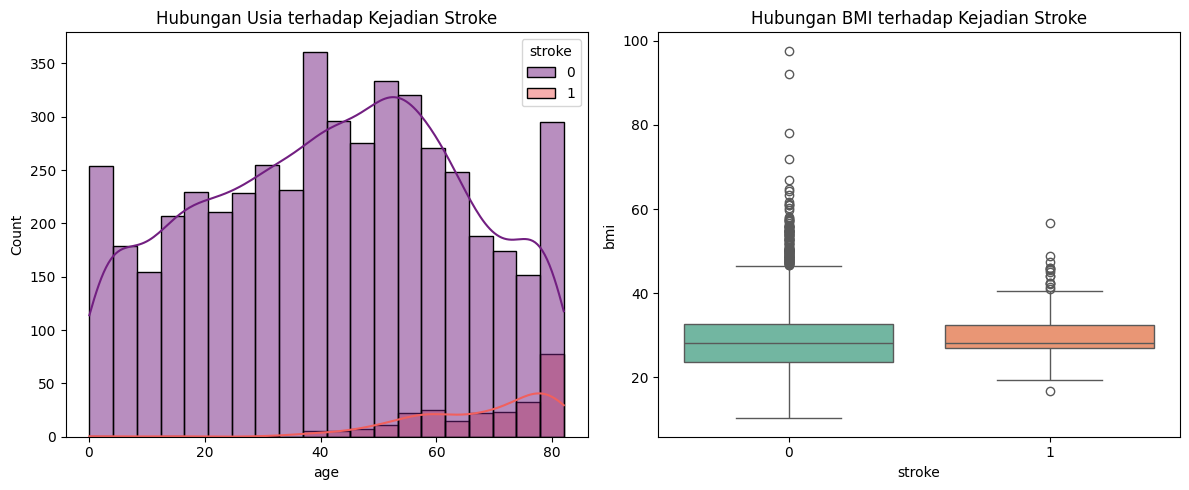

In [4]:
plt.figure(figsize=(12, 5))

# Visualisasi Usia vs Stroke
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', hue='stroke', kde=True, palette='magma')
plt.title('Hubungan Usia terhadap Kejadian Stroke')

# Visualisasi BMI vs Stroke
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='stroke', y='bmi', palette='Set2')
plt.title('Hubungan BMI terhadap Kejadian Stroke')

plt.tight_layout()
plt.show()

# **Machine Learning Modelling**

Membagi Data Latih (Training) dan Data Uji (Testing)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Mengonversi data kategori menjadi angka (Preprocessing)
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Menentukan fitur (X) dan target (y)
X = df.drop(['id', 'stroke'], axis=1) # Menghapus ID dan kolom target
y = df['stroke']

# Membagi data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Memilih Algoritma dan Melatih Model

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih model menggunakan data training
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluasi Akurasi Model

In [7]:
from sklearn.metrics import accuracy_score, classification_report

# Membuat prediksi
y_pred = rf_model.predict(X_test)

# Menampilkan hasil evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\nLaporan Klasifikasi Detail:")
print(classification_report(y_test, y_pred))

Akurasi Model: 93.93%

Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
